In [ ]:
!pip install emoji
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# read sample data from csv
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_review_data_binned.csv'
df_review_data_binned = pd.read_csv(file_path)

# Null value checking
print(df_review_data_binned.isnull().sum())
df_review_data_binned.info()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
review_id         0
user_id           0
business_id       0
stars             0
useful            0
funny             0
cool              0
text              0
date              0
stars_business    0
stars_binned      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144209 entries, 0 to 144208
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   review_id       144209 non-null  object 
 1   user_id         144209 non-null  object 
 2   business_id     144209 non-null  object 
 3   stars           144209 non-null  int64  
 4   useful          144209 non-null  int64  
 5   funny           144209 non-null  int64  
 6   cool            144209 non-null  int64  
 7   text            144209 non-null  object 
 8   date            144209 non-null  object 
 9   stars_business  

In [ ]:
# Pre-processing
import emoji
import re
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

df_review_data_binned = df_review_data_binned.dropna(subset=['stars_binned'])
df_review_data_binned = df_review_data_binned.dropna(subset=['text'])
print(df_review_data_binned.shape)


# Identify if there are any emoji characters

def clean_text(text):
  if text is None:
    return ""
  text = emoji.replace_emoji(text, replace='')
  # convert to lower case
  text = text.lower()
  # remove strings that start with http
  text = re.sub(r'http\S+', '', text)
  # remove HTML tags
  text = re.sub(r'<.*?>', '', text)
  # remove special characters
  text = re.sub(r'www\S+', '', text)
  # remove punctuations
  text = re.sub(r'[^\w\s]', '', text)
  # remove numbers
  text = re.sub(r'\d+', '', text)
  text = unicodedata.normalize('NFKD', text)
  text = text.encode('ascii', 'ignore').decode('utf-8')
  #remove any left non-ascii characters
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df_review_data_binned["text"] = df_review_data_binned["text"].apply(clean_text)
# download stopwords
nltk.download('stopwords')
# download tokenizer data
nltk.download('punkt_tab')
# remove stopwords
stop_words = set(stopwords.words('english'))
# remove stopwords from text column
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
# perform lemitazation
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
# download lexical database
nltk.download('wordnet')
# multilingual lexical database
nltk.download('omw-1.4')
# perform lemmatization
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x)]))




(144209, 11)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from sklearn.model_selection import train_test_split
# define X and y
X = df_review_data_binned[["text","useful"]]
y = df_review_data_binned['stars_binned']

# Split all data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Take only text
X_train_text = X_train['text']
X_test_text = X_test['text']


In [ ]:

# TfidfVectorizer (from sklearn.feature_extraction.text) converts raw text into numerical feature vectors using the TF-IDF weighting scheme.
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    min_df=5, # ignore words that appear in < 5 documents,
    max_df=0.8, # ignore words that appear in > 80% of the documents,
    max_features=10000,
    ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_text.tolist())
X_test_tfidf = vectorizer.transform(X_test_text.tolist())



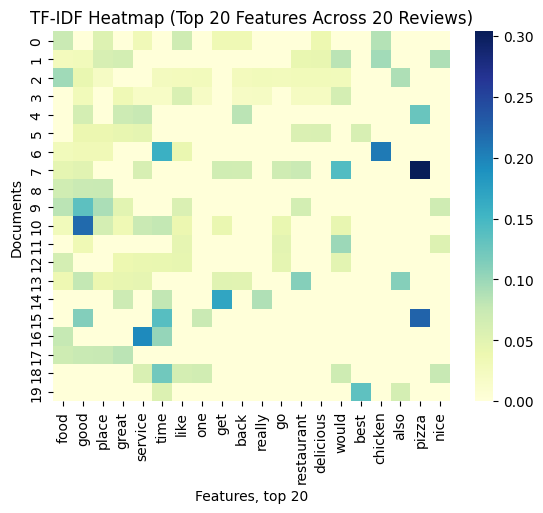

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Plot heatmap of top 20 features
#Sum TF-IDF scores for each feature across all documents
feature_sums = np.array(X_train_tfidf.sum(axis=0)).flatten()
feature_names = np.array(vectorizer.get_feature_names_out())

# Create a pandas Series and sort
top_features = pd.Series(feature_sums, index=feature_names).sort_values(ascending=False).head(20)

# Select top features to plot
top_feature_indices = [vectorizer.vocabulary_[f] for f in top_features.index]
X_top = X_train_tfidf[:, top_feature_indices].toarray()[:20]  # first 20 docs

# Plot heatmap
sns.heatmap(X_top, cmap="YlGnBu", xticklabels=top_features.index)
plt.title("TF-IDF Heatmap (Top 20 Features Across 20 Reviews)")
plt.xlabel("Features, top 20")
plt.ylabel("Documents")
plt.show()


This section of the code applies  **Chi2** feature selection with various values of **k**,  to retain the most informative terms and visualizes selected features with **word cloud**

Selected features (k): 1000
Shapes -> Train: (115367, 1000), Test: (28842, 1000)


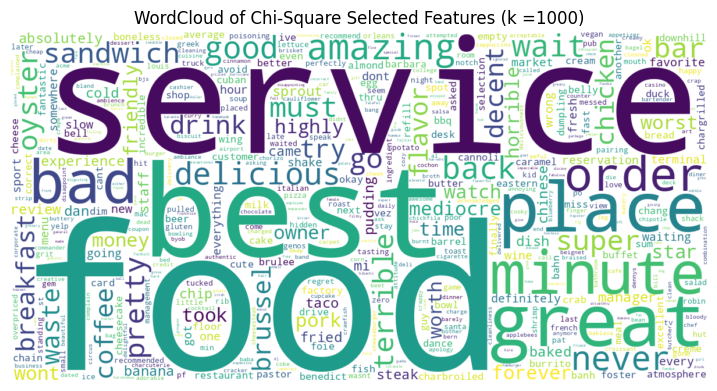



Selected features (k): 2000
Shapes -> Train: (115367, 2000), Test: (28842, 2000)


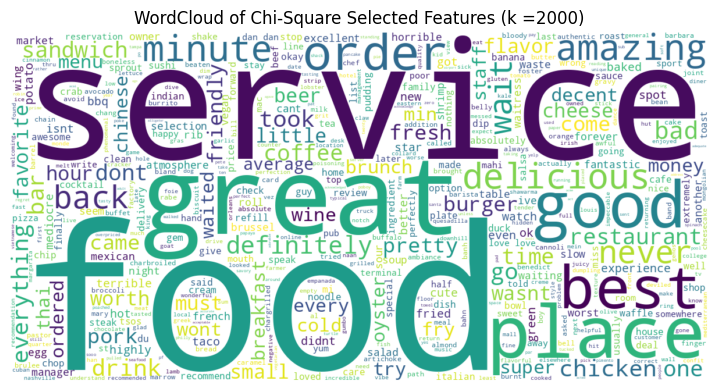

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from wordcloud import WordCloud

k_values = [1000, 2000]
results = []
selected_features = {}
X_train_chi2_selection = {}
X_test_chi2_selection = {}

for k in k_values:
  # Mutual Information feature selection based, differnt numberof features selected for comparison
  selector = SelectKBest(score_func=chi2, k=k)
  X_train_chi2_selection[k] = selector.fit_transform(X_train_tfidf, y_train)
  X_test_chi2_selection[k]  = selector.transform(X_test_tfidf)

  # all feature names after TF-IDF
  all_features_after_tfidf = vectorizer.get_feature_names_out()

  # Align feature names with selected indices
  selected_features[k] = all_features_after_tfidf[selector.get_support()]

  print(f"Selected features (k): {X_train_chi2_selection[k].shape[1]}")
  print(f"Shapes -> Train: {X_train_chi2_selection[k].shape}, Test: {X_test_chi2_selection[k].shape}")

  selected_text = " ".join(selected_features[k])

  wordcloud = WordCloud(
      width=1200,
      height=600,
      background_color="white",
      colormap="viridis",
      max_words=500,
      random_state=42
  ).generate(selected_text)

  # Plot
  plt.figure(figsize=(9, 6))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"WordCloud of Chi-Square Selected Features (k ={k})", fontsize=12)
  plt.show()
  print('\n')


In [ ]:
def _evaluate_feature_subset(
        model,
        X_train,
        y_train,
        X_valid,
        y_valid,
        feature_indices,
        scoring,
        score_average
):
    """Fit model on selected features and return validation score."""
    X_train_subset = X_train[:, feature_indices]
    X_valid_subset = X_valid[:, feature_indices]
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_valid_subset)
    return scoring(y_valid, y_pred, average=score_average)

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
import time

def batched_forward_selection(
    X,
    y,
    n_features_to_select=300,
    batch_size=20,
    val_size=0.1,
    random_state=42,
    scoring=f1_score,
    score_average="macro",
):

    """Perform batched forward feature selection using Logistic Regression.

    Parameters
    ----------
    X : train feature matrix (n_samples, n_features)

    y : target(n_samples)

    n_features_to_select : int, default=300
    Number of features to select.

    batch_size : int, default=20
    Number of features to add per iteration.

    val_size : float, default=0.2
    breakdown of data in the validation split.

    random_state : int, default=42
    random statefor reproducibility.

    scoring : callable, default=f1_score
    scoring function to use.

    score_average : str, default="macro"
    average parameter for scoring function.

    Returns
    -------
    selected : list of int
    Indices of the selected features.
    """
    X_train_batch, X_val_batch, y_train_batch, y_val_batch = train_test_split(
        X, y, test_size=val_size, random_state=random_state, stratify=y
    )
    log_regression = LogisticRegression(
        max_iter=5000,
        solver="saga", # used for multiclass,
        n_jobs=-1,
        penalty='l2',
        class_weight = 'balanced'
    )

    n_samples, n_features = X_train_batch.shape
    selected = []
    remaining = list(range(n_features))

    while len(selected) < n_features_to_select and remaining:

      scores_this_round = []
      for feature_index in remaining:
          candidate_feature = selected + [feature_index]

          score = _evaluate_feature_subset(
              model = log_regression,
              X_train = X_train_batch,
              y_train = y_train_batch,
              X_valid = X_val_batch,
              y_valid = y_val_batch,
              feature_indices = candidate_feature,
              scoring = scoring,
              score_average = score_average
          )
          scores_this_round.append((feature_index, score))

      # pick best batch
      scores_this_round.sort(key=lambda x: x[1], reverse=True)
      best_batch = []
      for feat, score in scores_this_round[:batch_size]:
        best_batch.append(feat)
      selected.extend(best_batch)

      # get remaining fearutes (one that is not selected)
      remaining = [i for i in remaining if i not in best_batch]

      # print at what time features selected
      print(f'Selected at {time.strftime("%Y-%m-%d %H:%M:%S")}: {len(selected)} / {n_features_to_select}')
    return selected[:n_features_to_select]




In [ ]:
# Common method to evaluate model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, k_value):
    """
    Evaluates a machine learning model using training and testing data, and prints various evaluation metrics including accuracy, classification report, macro F1-score, and weighted F1-score. The function also returns the predicted labels for the test dataset.
    """

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nEvaluation Metrics {model_name} chi2 k = {k_value} FS selection")
    print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("Macro F1-score:", f1_score(y_test, y_pred, average="macro", zero_division=0))
    print("Weighted F1-score:", f1_score(y_test, y_pred, average="weighted", zero_division=0))

    return y_pred

def plot_confusion_matrices(model_name, y_test, y_pred, k_value):
  """
  Plots confusion matrices for Models
  """
  cmaps = [
    "Blues", "Greens", "Purples", "Oranges", "Reds",
    "viridis", "plasma", "inferno", "magma", "cividis",
    "YlGnBu", "YlOrRd", "PuBuGn", "GnBu", "BuPu",
  ]

  cmap_choice = random.choice(cmaps)

  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=cmap_choice)
  plt.title(f"Confusion Matrix – {model_name} chi2 {k_value} - FS Selection")
  plt.show()


- Executes a custom **forward feature selection** process to further reduce dimensionality.
- Trains and evaluates multiple classifiers
  (**Logistic Regression**, **Multinomial Naive Bayes**, **Decision Tree**, **Random Forest**) on the chosen features using the holdout test set.
- Compares model performance using F1 score and accurcy score
- Uses starfified K-Fold CV to evaluate and compare models



Selected chi2 features: 1000 FS features: 500
Selected at 2025-12-01 20:15:29: 50 / 500
Selected at 2025-12-01 20:23:45: 100 / 500
Selected at 2025-12-01 20:39:58: 150 / 500
Selected at 2025-12-01 20:55:59: 200 / 500
Selected at 2025-12-01 21:12:06: 250 / 500
Selected at 2025-12-01 21:27:58: 300 / 500
Selected at 2025-12-01 21:42:04: 350 / 500
Selected at 2025-12-01 21:55:23: 400 / 500
Selected at 2025-12-01 22:08:05: 450 / 500
Selected at 2025-12-01 22:20:10: 500 / 500
CV Logistic Regression, (k1000) F1 macro per fold:[0.38719758 0.3858645  0.3829297  0.3868112  0.38447764]
CV Logistic Regression, (k1000) mean=0.3854561234294571, std=0.0015732702115975063

Evaluation Metrics Logistic Regression chi2 k = 1000 FS selection
Logistic Regression Accuracy: 0.38443935926773454
Classification report:
               precision    recall  f1-score   support

           1       0.33      0.58      0.42      4124
           2       0.32      0.26      0.29      6732
           3       0.53      0.

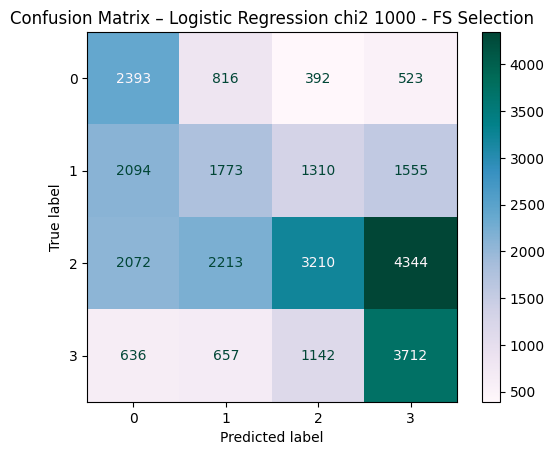

CV Naive Bayes, (k1000) F1 macro per fold:[0.19356354 0.19382076 0.18774861 0.18947111 0.18749921]
CV Naive Bayes, (k1000) mean=0.19042064509883874, std=0.0027573461509821616

Evaluation Metrics Multinomial Naive Bayes chi2 k = 1000 FS selection
Multinomial Naive Bayes Accuracy: 0.4221274530199015
Classification report:
               precision    recall  f1-score   support

           1       0.72      0.07      0.12      4124
           2       0.42      0.01      0.01      6732
           3       0.42      0.99      0.59     11839
           4       0.71      0.01      0.03      6147

    accuracy                           0.42     28842
   macro avg       0.57      0.27      0.19     28842
weighted avg       0.52      0.42      0.27     28842

Macro F1-score: 0.18793139844944046
Weighted F1-score: 0.2676853380352952


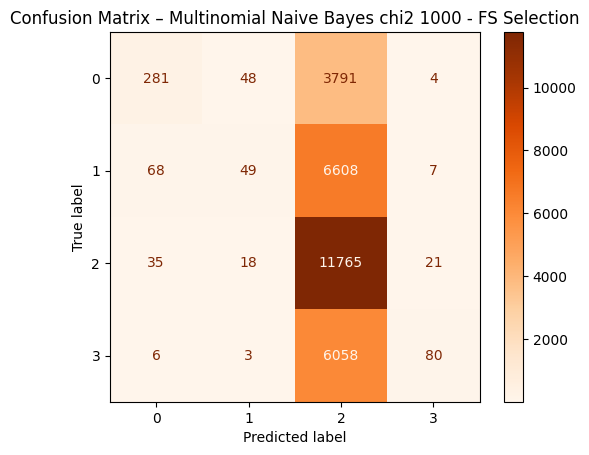

CV Decision Tree, (k1000) F1 macro per fold:[0.24655605 0.25503208 0.23838141 0.24883689 0.24806014]
CV Decision Tree, (k1000) mean=0.24737331565430093, std=0.005344020288140704

Evaluation Metrics Decision Tree chi2 k = 1000 FS selection
Decision Tree Accuracy: 0.40812010262811177
Classification report:
               precision    recall  f1-score   support

           1       0.39      0.12      0.19      4124
           2       0.27      0.06      0.10      6732
           3       0.42      0.89      0.57     11839
           4       0.34      0.06      0.10      6147

    accuracy                           0.41     28842
   macro avg       0.35      0.28      0.24     28842
weighted avg       0.36      0.41      0.31     28842

Macro F1-score: 0.2391396045884368
Weighted F1-score: 0.3052711979196682


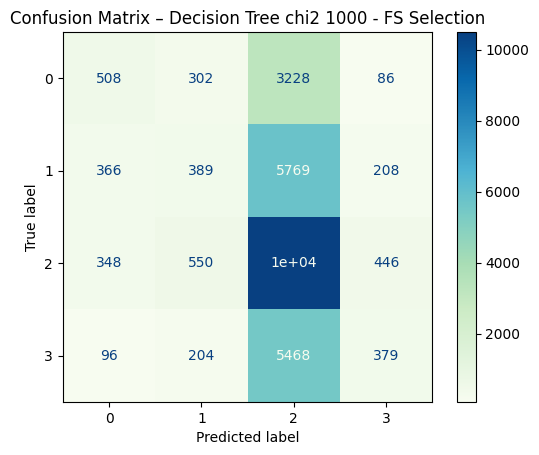

CV Decision Tree, (k1000) F1 macro per fold:[0.31855729 0.32657423 0.3214523  0.31545496 0.31792183]
CV Decision Tree, (k1000) mean=0.3199921209330906, std=0.003804916054385598

Evaluation Metrics Random Forest chi2 k = 1000 FS selection
Random Forest Accuracy: 0.4299979197004369
Classification report:
               precision    recall  f1-score   support

           1       0.46      0.26      0.33      4124
           2       0.32      0.09      0.15      6732
           3       0.44      0.82      0.57     11839
           4       0.43      0.16      0.24      6147

    accuracy                           0.43     28842
   macro avg       0.41      0.33      0.32     28842
weighted avg       0.41      0.43      0.37     28842

Macro F1-score: 0.32041175410240247
Weighted F1-score: 0.3656614664478128


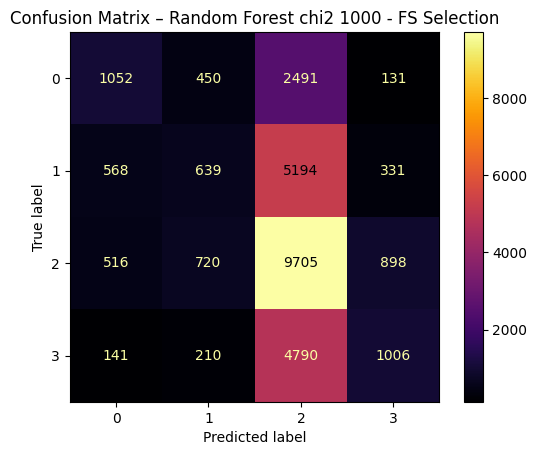

Selected chi2 features: 2000 FS features: 500
Selected at 2025-12-01 22:43:28: 50 / 500
Selected at 2025-12-01 22:59:03: 100 / 500
Selected at 2025-12-01 23:29:10: 150 / 500
Selected at 2025-12-02 00:03:37: 200 / 500
Selected at 2025-12-02 00:39:18: 250 / 500
Selected at 2025-12-02 01:16:27: 300 / 500
Selected at 2025-12-02 01:55:57: 350 / 500
Selected at 2025-12-02 02:36:08: 400 / 500
Selected at 2025-12-02 03:16:25: 450 / 500
Selected at 2025-12-02 03:57:25: 500 / 500
CV Logistic Regression, (k2000) F1 macro per fold:[0.38534224 0.3843192  0.38170899 0.39062438 0.38742894]
CV Logistic Regression, (k2000) mean=0.3858847504322419, std=0.0030010256892585322

Evaluation Metrics Logistic Regression chi2 k = 2000 FS selection
Logistic Regression Accuracy: 0.3854101657305319
Classification report:
               precision    recall  f1-score   support

           1       0.33      0.59      0.43      4124
           2       0.32      0.25      0.28      6732
           3       0.52      0.2

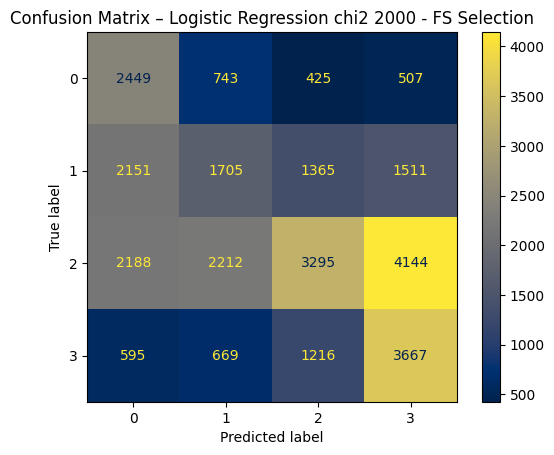

CV Naive Bayes, (k2000) F1 macro per fold:[0.1809964  0.18220619 0.18028109 0.17572066 0.1768431 ]
CV Naive Bayes, (k2000) mean=0.1792094892791068, std=0.0024937271135941743

Evaluation Metrics Multinomial Naive Bayes chi2 k = 2000 FS selection
Multinomial Naive Bayes Accuracy: 0.4198391235004507
Classification report:
               precision    recall  f1-score   support

           1       0.74      0.06      0.11      4124
           2       0.42      0.01      0.01      6732
           3       0.42      1.00      0.59     11839
           4       0.76      0.01      0.01      6147

    accuracy                           0.42     28842
   macro avg       0.58      0.27      0.18     28842
weighted avg       0.54      0.42      0.26     28842

Macro F1-score: 0.18044164205815436
Weighted F1-score: 0.2618982644383502


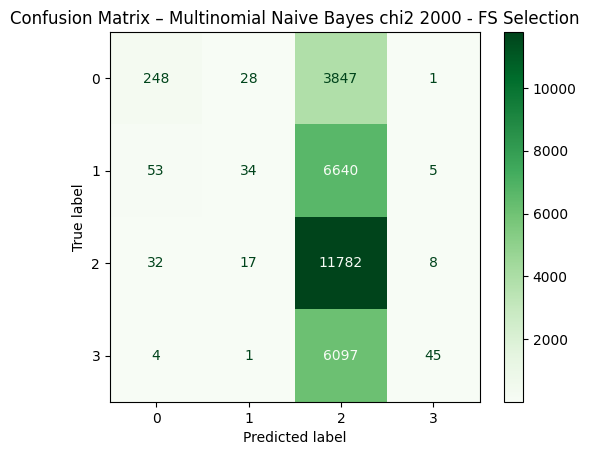

CV Decision Tree, (k2000) F1 macro per fold:[0.2513339  0.25422426 0.23830888 0.24396923 0.24494602]
CV Decision Tree, (k2000) mean=0.24655645675093893, std=0.0056378884038827005

Evaluation Metrics Decision Tree chi2 k = 2000 FS selection
Decision Tree Accuracy: 0.40860550585951044
Classification report:
               precision    recall  f1-score   support

           1       0.36      0.13      0.19      4124
           2       0.28      0.07      0.11      6732
           3       0.42      0.86      0.57     11839
           4       0.37      0.09      0.14      6147

    accuracy                           0.41     28842
   macro avg       0.36      0.29      0.25     28842
weighted avg       0.37      0.41      0.32     28842

Macro F1-score: 0.25414003381201383
Weighted F1-score: 0.3174995036708262


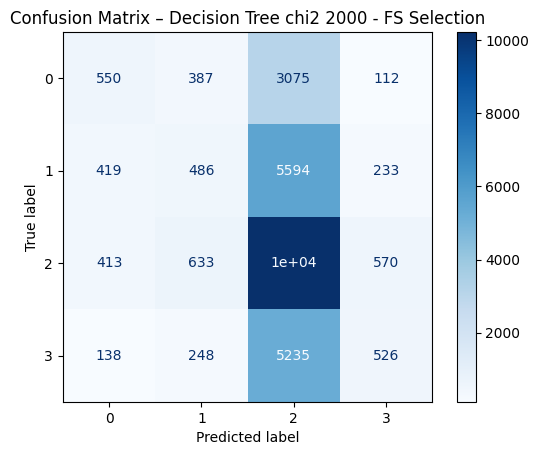

CV Decision Tree, (k2000) F1 macro per fold:[0.30667793 0.31607504 0.31388506 0.3057766  0.30619582]
CV Decision Tree, (k2000) mean=0.3097220888234058, std=0.004357950119383289

Evaluation Metrics Random Forest chi2 k = 2000 FS selection
Random Forest Accuracy: 0.43606546009292
Classification report:
               precision    recall  f1-score   support

           1       0.47      0.25      0.33      4124
           2       0.33      0.08      0.12      6732
           3       0.44      0.86      0.58     11839
           4       0.45      0.13      0.20      6147

    accuracy                           0.44     28842
   macro avg       0.42      0.33      0.31     28842
weighted avg       0.42      0.44      0.36     28842

Macro F1-score: 0.3085722516073997
Weighted F1-score: 0.35718459529667046


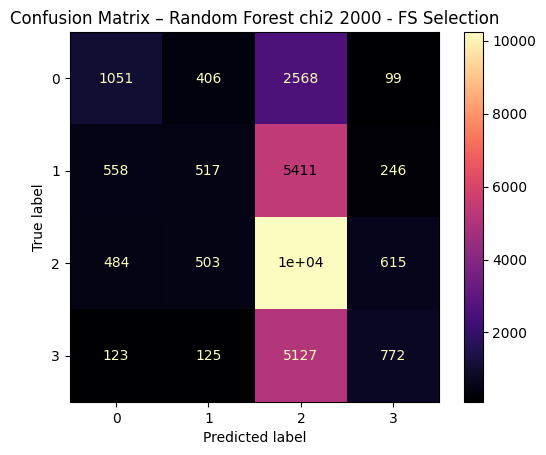

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Run forward selection for features of different sizes selected after ch2
selected_idx = {}
final_feature_names = {}
final_feature_size = 500

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for key in X_test_chi2_selection.keys():
  print(f"Selected chi2 features: {X_train_chi2_selection[key].shape[1]} FS features: {final_feature_size}")
  selected_idx[key] = batched_forward_selection(
    X_train_chi2_selection[key],
    y_train,
    n_features_to_select=final_feature_size,  # change if needed
    batch_size=50,
    val_size=0.1,
    random_state=42,
)
  # map to features

  final_feature_names[key] = selected_features[key][selected_idx[key]]

  X_train_after_fs = X_train_chi2_selection[key][:, selected_idx[key]]
  X_test_after_fs  = X_test_chi2_selection[key][:, selected_idx[key]]

  # Run logistic regression
  logistic_regression= LogisticRegression(max_iter=3000,
                         n_jobs=-1,
                         solver="saga",
                         penalty='l2', # improves reall for manority classes
                         class_weight = 'balanced')

  # Cross validation Score on Training data for Model comparison
  lr_scores = cross_val_score(
      logistic_regression,
      X_train_after_fs,
      y_train,
      cv=skfold,
      scoring='f1_macro',
      n_jobs=-1
  )

  print(f"CV Logistic Regression, (k{key}) F1 macro per fold:{lr_scores}")
  print(f"CV Logistic Regression, (k{key}) mean={lr_scores.mean()}, std={lr_scores.std()}")

  y_pred = evaluate_model(logistic_regression, "Logistic Regression", X_train_after_fs, y_train, X_test_after_fs, y_test, key)
  plot_confusion_matrices("Logistic Regression", y_test, y_pred, key)

  # Run Naive Bayes model
  nb = MultinomialNB()
  nb.fit(X_train_after_fs, y_train)

  # Cross validation Score on Training data for Model comparison
  nb_scores = cross_val_score(
      nb,
      X_train_after_fs,
      y_train,
      cv=skfold,
      scoring='f1_macro',
      n_jobs=-1
  )

  print(f"CV Naive Bayes, (k{key}) F1 macro per fold:{nb_scores}")
  print(f"CV Naive Bayes, (k{key}) mean={nb_scores.mean()}, std={nb_scores.std()}")

  y_pred = evaluate_model(nb, "Multinomial Naive Bayes", X_train_after_fs, y_train, X_test_after_fs, y_test, key)
  plot_confusion_matrices("Multinomial Naive Bayes", y_test, y_pred, key)

  # Run decision Tree
  dt = DecisionTreeClassifier(
      criterion="gini",   # or "entropy"
      max_depth=20,       # keep it from overfitting on text
      min_samples_leaf=5, # smooth leaves a bit
      random_state=42
  )
  # Cross validation Score on Training data for Model comparison
  dt_scores = cross_val_score(
      dt,
      X_train_after_fs,
      y_train,
      cv=skfold,
      scoring='f1_macro',
      n_jobs=-1
  )

  print(f"CV Decision Tree, (k{key}) F1 macro per fold:{dt_scores}")
  print(f"CV Decision Tree, (k{key}) mean={dt_scores.mean()}, std={dt_scores.std()}")

  y_pred = evaluate_model(dt, "Decision Tree", X_train_after_fs, y_train, X_test_after_fs, y_test, key)
  plot_confusion_matrices("Decision Tree", y_test, y_pred, key)

  # Run Random forest classifier


  rf = RandomForestClassifier(
      n_estimators=200,
      class_weight = 'balanced',
      max_depth=None,
      n_jobs=-1,
      random_state=42
  )

  # Cross validation Score on Training data for Model comparison
  rf_scores = cross_val_score(
      rf,
      X_train_after_fs,
      y_train,
      cv=skfold,
      scoring='f1_macro',
      n_jobs=-1
  )

  print(f"CV Decision Tree, (k{key}) F1 macro per fold:{rf_scores}")
  print(f"CV Decision Tree, (k{key}) mean={rf_scores.mean()}, std={rf_scores.std()}")

  y_pred = evaluate_model(rf, "Random Forest", X_train_after_fs, y_train, X_test_after_fs, y_test, key)
  plot_confusion_matrices("Random Forest", y_test, y_pred, key)